# Exploratory Data Analysis: Red Wine Quality

**PKCERT AI & Software Development Internship — Task 06**

*Author: Abdullah Amir*

This notebook walks through a full exploratory data analysis of the UCI Red
Wine Quality dataset. The goal is to understand what the data looks like, clean
up any issues, and figure out which chemical properties actually relate to how
a wine is rated. Each stage has a short markdown note explaining what is going
on and what the output is telling us.

## Part A — Dataset Selection & Description

**Dataset:** Red Wine Quality
**Source:** UCI Machine Learning Repository
(`https://archive.ics.uci.edu/ml/datasets/wine+quality`), originally from
Cortez et al., 2009.

**Purpose:** Each row is a red *vinho verde* wine from Portugal. Eleven
physicochemical lab measurements (things like alcohol, acidity, and sulphates)
were recorded, and a panel of tasters scored each wine for quality. The point
of the dataset is to see whether those chemical measurements can explain, or
even predict, the quality score.

**Records:** 1,599 wines.

**Features (11, all numeric):** fixed acidity, volatile acidity, citric acid,
residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density,
pH, sulphates, and alcohol.

**Target variable:** `quality`, an integer score (in practice 3 to 8) given by
wine tasters. This is what we want to explain.

In [1]:
# Core libraries for the analysis
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# save every figure to figures/ so the report can reuse them
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}", dpi=120, bbox_inches="tight")

In [2]:
# The UCI file is semicolon separated, not comma separated
df = pd.read_csv("winequality-red.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Part B — Exploratory Data Analysis

### B1. Structure, Data Types, and Summary Statistics

First a look at the shape of the table, the type of each column, and the basic
summary statistics.

In [3]:
print("Rows, columns:", df.shape)
print()
df.info()

Rows, columns: (1599, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# Summary statistics for every (numeric) column
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


A few things stand out already:

- All twelve columns are numeric, so there is no text to encode.
- The scales are very different: `total sulfur dioxide` runs into the hundreds
  while `density` sits right around 1. That matters if we ever model this data.
- `quality` ranges from 3 to 8 with a mean near 5.6, so most wines are average
  rather than excellent or terrible.

### B2. Missing Values, Duplicates, and Inconsistencies

In [5]:
# Missing values per column
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
print(missing[missing > 0] if missing.sum() else "No missing values in any column.")

Total missing values: 0
No missing values in any column.


In [6]:
# Duplicate rows
dupes = df.duplicated().sum()
print("Fully duplicated rows:", dupes)

# Drop the duplicates so repeated wines do not get double weight
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Fully duplicated rows: 240
Shape after dropping duplicates: (1359, 12)


The dataset is clean on missing values: there are none, which is unusual and
convenient. It does contain **240 duplicate rows** though. These could be
genuine different wines that happened to record identical measurements, but to
be safe we drop them so they do not over-weight the analysis. That leaves
**1,359 unique rows**.

There are no obvious inconsistencies either: all measurements are positive and
sit in physically sensible ranges (for example pH between about 2.7 and 4.0,
which is right for wine).

### B3. Visualizations

Below are six visualizations, each followed by a short interpretation.

**Visualization 1 — Distribution of the quality score.**

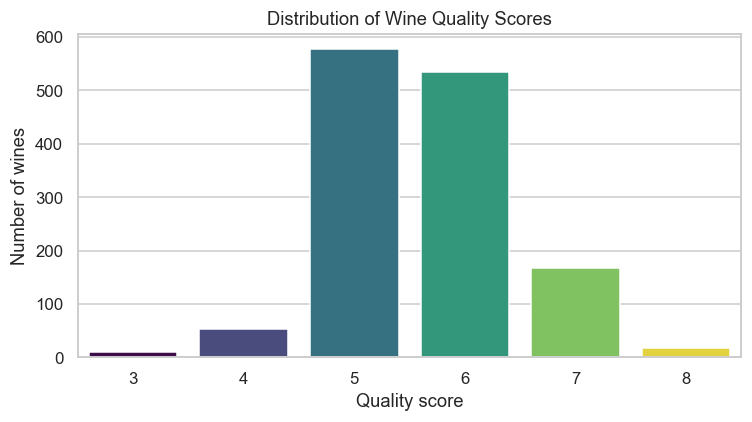

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="quality", hue="quality",
              palette="viridis", legend=False)
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
save_fig("01_quality_distribution.png")
plt.show()

The quality scores are heavily concentrated on 5 and 6. Very few wines are
rated 3, 4, or 8. This class imbalance is important: any model trained on this
data will see very few great or poor wines, so it will naturally be best at
telling apart the average ones.

**Visualization 2 — Distributions of all the chemical features.**

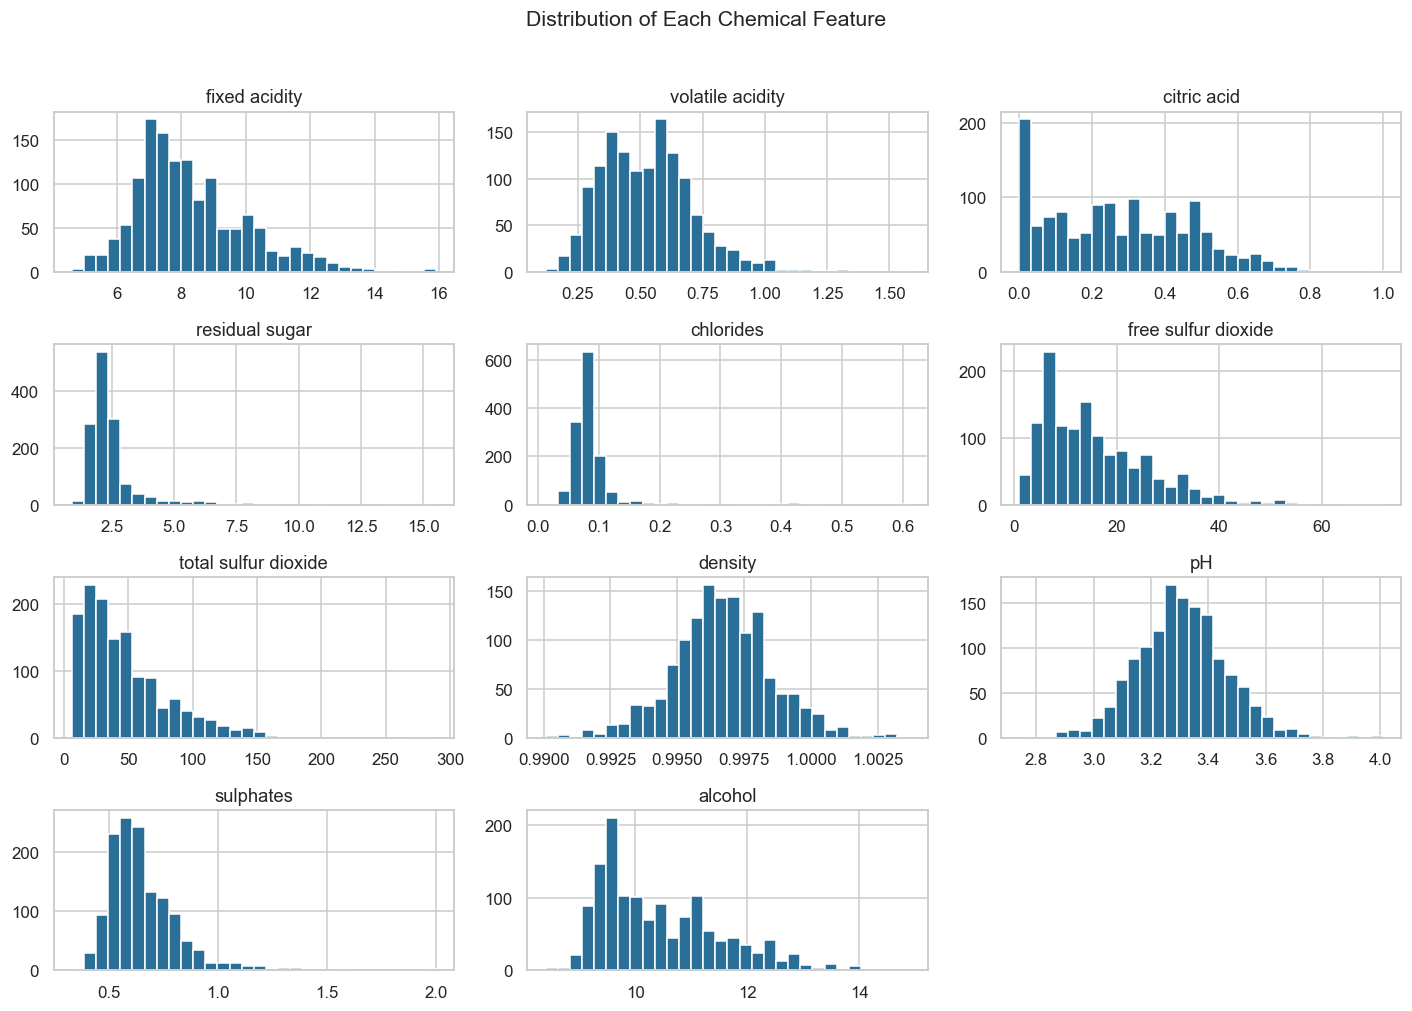

In [8]:
feature_cols = [c for c in df.columns if c != "quality"]
df[feature_cols].hist(figsize=(13, 9), bins=30, color="#2a6f97",
                      edgecolor="white")
plt.suptitle("Distribution of Each Chemical Feature", y=1.02, fontsize=14)
save_fig("02_feature_histograms.png")
plt.show()

Most features are right skewed, with a long tail of high values. `residual
sugar` and `chlorides` are the most extreme, with a few wines sitting far out to
the right. `alcohol` is skewed too but more gently. This skew tells us that a
handful of wines are chemically unusual, and that scaling would help before any
distance-based modelling.

**Visualization 3 — Correlation heatmap.**

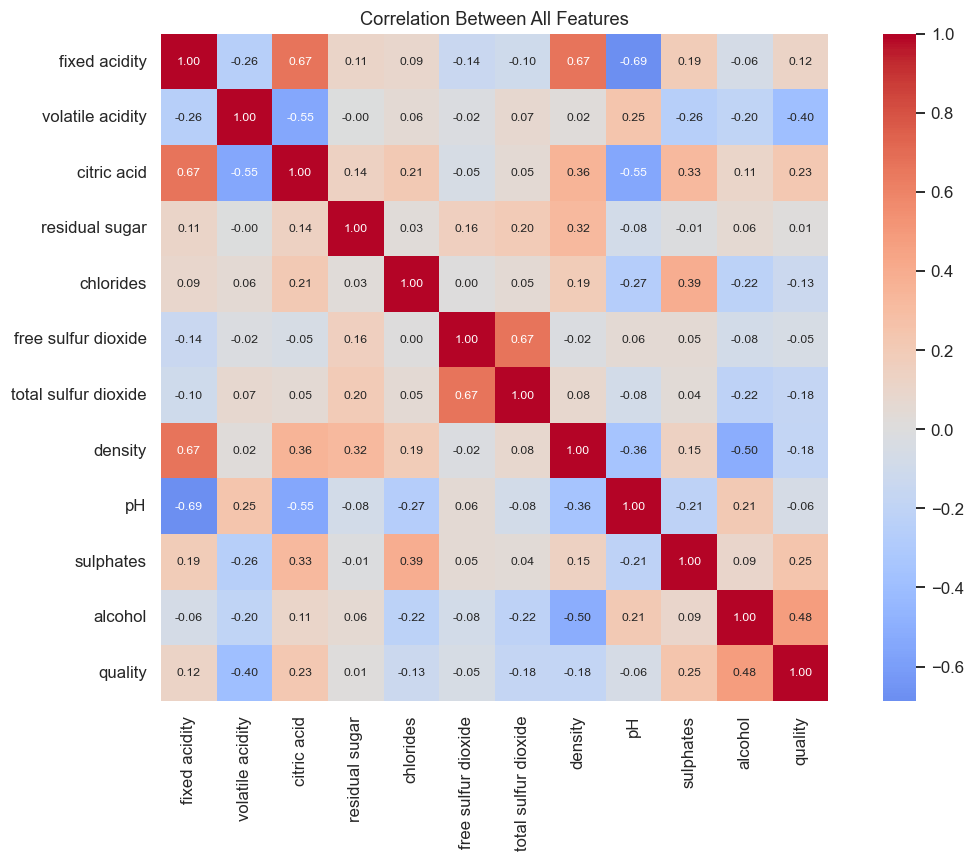

In [9]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, annot_kws={"size": 8})
plt.title("Correlation Between All Features")
save_fig("03_correlation_heatmap.png")
plt.show()

The heatmap is the heart of the analysis. Reading the `quality` row,
`alcohol` has the strongest positive correlation (about +0.48) and `volatile
acidity` the strongest negative one (about -0.39). Among the features
themselves, `fixed acidity` is tied to both `citric acid` and `density`, and
`free` and `total sulfur dioxide` move together, which all makes chemical
sense.

**Visualization 4 — Alcohol content across quality levels.**

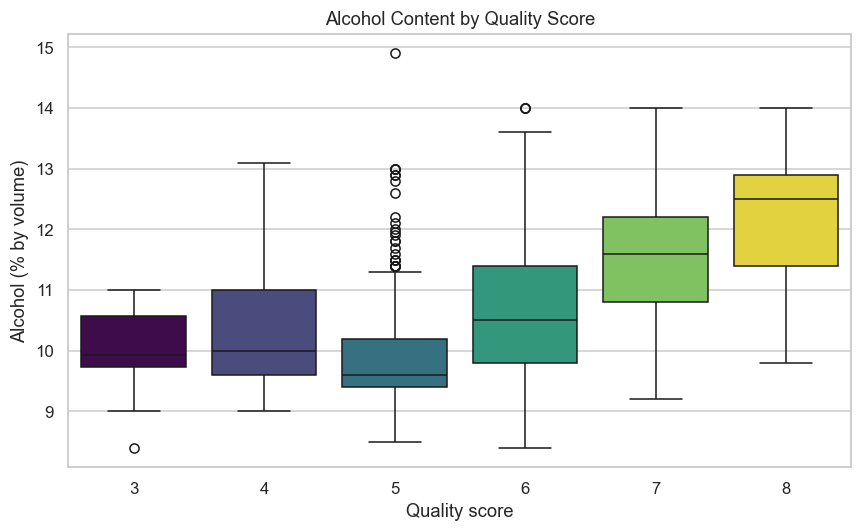

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="quality", y="alcohol", hue="quality",
            palette="viridis", legend=False)
plt.title("Alcohol Content by Quality Score")
plt.xlabel("Quality score")
plt.ylabel("Alcohol (% by volume)")
save_fig("04_alcohol_by_quality.png")
plt.show()

This is the clearest relationship in the whole dataset. As the quality score
goes up, the median alcohol content climbs steadily. Higher rated wines tend to
be more alcoholic, which lines up with the strong positive correlation we saw in
the heatmap.

**Visualization 5 — Volatile acidity across quality levels.**

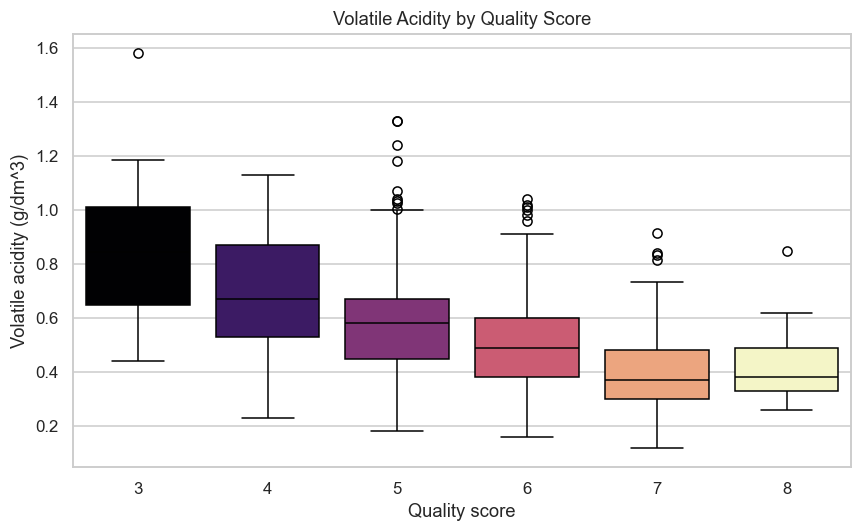

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="quality", y="volatile acidity", hue="quality",
            palette="magma", legend=False)
plt.title("Volatile Acidity by Quality Score")
plt.xlabel("Quality score")
plt.ylabel("Volatile acidity (g/dm^3)")
save_fig("05_volatile_acidity_by_quality.png")
plt.show()

This is the mirror image of the alcohol chart. Volatile acidity is what gives
wine a sharp vinegar taste, and here the median falls as quality rises. Tasters
clearly marked down the more acidic wines, which explains the negative
correlation.

**Visualization 6 — Which features relate most to quality.**

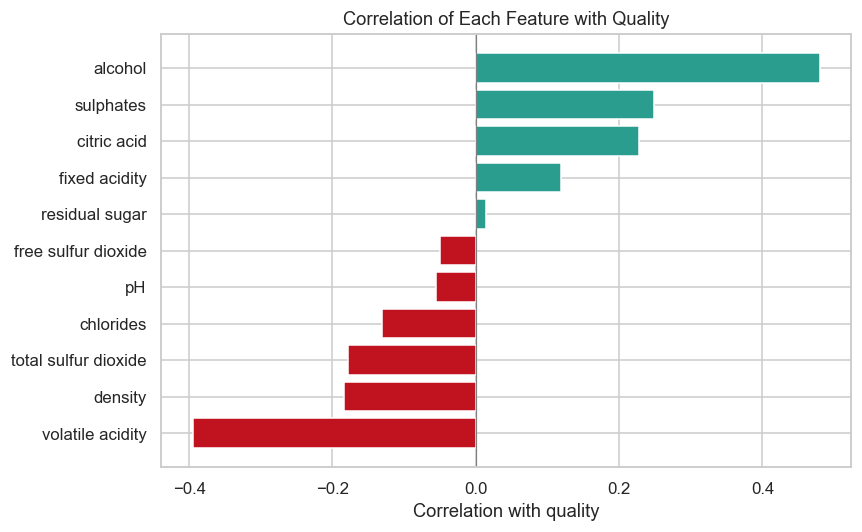

In [12]:
corr_q = df.corr()["quality"].drop("quality").sort_values()
plt.figure(figsize=(8, 5))
colors = ["#c1121f" if v < 0 else "#2a9d8f" for v in corr_q.values]
plt.barh(corr_q.index, corr_q.values, color=colors)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Correlation of Each Feature with Quality")
plt.xlabel("Correlation with quality")
save_fig("06_correlation_with_quality.png")
plt.show()

Lining the correlations up in one bar chart gives a tidy summary. On the
positive side, `alcohol`, `sulphates`, and `citric acid` help a wine's score. On
the negative side, `volatile acidity` hurts it the most, followed by `total
sulfur dioxide`, `density`, and `chlorides`. Everything else is close to zero,
meaning it has little linear link to quality on its own.

## Part C — Written Analysis & Insights

### Key Findings

- **Quality is driven mostly by a few features.** Alcohol (positive) and
  volatile acidity (negative) are by far the two strongest signals, with
  sulphates and citric acid giving a smaller positive nudge.
- **Higher alcohol means higher ratings.** The median alcohol content rises with
  every step up in quality score.
- **Sharp, acidic wines score badly.** Volatile acidity, the vinegar note, falls
  steadily as quality improves.
- **The data is imbalanced.** Most wines are rated 5 or 6, with very few at the
  extremes.

### Patterns, Correlations, and Possible Insights

For a winemaker, the practical takeaway is that pushing for a good fermentation
(higher alcohol) while keeping volatile acidity low is the chemical recipe most
associated with better-rated wine. Sulphates, which act as a preservative and
antioxidant, also line up with slightly better scores. From a research angle,
the fact that no single feature correlates above about 0.5 with quality suggests
the rating is genuinely multi-factor, so a model that combines features (rather
than any one measurement) is the right tool.

### Limitations and Future Work

- **Class imbalance** is the biggest limitation. With so few 3, 4, and 8 rated
  wines, it is hard to say much about what makes a wine truly great or truly
  poor.
- **Subjective target.** Quality is an average of human taste scores, so it
  carries the tasters' personal bias.
- **Red wine only, one region.** These are all Portuguese *vinho verde* reds, so
  the findings may not carry over to other wines.
- **Future analysis** could merge in the white wine dataset for a bigger, more
  balanced picture, group the scores into low / medium / high to ease the
  imbalance, and train a classification model to see how well these features
  actually predict quality out of sample.

## Part D — Notebook Organization

This notebook is deliberately laid out to follow the task structure: dataset
description, then the exploratory analysis (structure, data quality, and
visualizations with interpretation), then the written insights. Markdown
headings separate each stage, code cells are commented, and every chart is
followed by a short note on what it shows. All figures are also saved into the
`figures/` folder so they can be reused in the accompanying report.